In [2]:
!pip install missingno

In [3]:
# ===============================
# 📦 Step 1: Import Libraries
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")
%matplotlib inline

In [4]:
# ===============================
# 📂 Step 2: Load Data
# ===============================
# Change 'your_dataset.csv' to your actual file name
file_path = '/content/drive/MyDrive/combined.csv'
df = pd.read_csv(file_path)

# Basic overview
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (2830743, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [5]:
# ===============================
# 🧾 Step 3: Data Overview
# ===============================
# Data types and non-null counts
df.info()

# Summary statistics
df.describe(include='all').T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         int64  
 11   Bwd Packet Length Min        int64  
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18   Flow IAT Max         

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Destination Port,2830743.0,NaN,NaN,NaN,8071.482501,18283.632172,0.0,53.0,80.0,443.0,65535.0
Flow Duration,2830743.0,NaN,NaN,NaN,14785663.929522,33653744.085855,-13.0,155.0,31316.0,3204828.5,119999998.0
Total Fwd Packets,2830743.0,NaN,NaN,NaN,9.36116,749.672792,1.0,2.0,2.0,5.0,219759.0
Total Backward Packets,2830743.0,NaN,NaN,NaN,10.39377,997.388269,0.0,1.0,2.0,4.0,291922.0
Total Length of Fwd Packets,2830743.0,NaN,NaN,NaN,549.302415,9993.589229,0.0,12.0,62.0,187.0,12900000.0
...,...,...,...,...,...,...,...,...,...,...,...
Idle Mean,2830743.0,NaN,NaN,NaN,8316036.627208,23630078.577951,0.0,0.0,0.0,0.0,120000000.0
Idle Std,2830743.0,NaN,NaN,NaN,503843.949779,4602984.480672,0.0,0.0,0.0,0.0,76900000.0
Idle Max,2830743.0,NaN,NaN,NaN,8695751.984586,24366888.329043,0.0,0.0,0.0,0.0,120000000.0
Idle Min,2830743.0,NaN,NaN,NaN,7920031.014637,23363418.927478,0.0,0.0,0.0,0.0,120000000.0


🔍 Missing values summary:
              Missing Values  Percentage
Flow Bytes/s            1358    0.047973

🧾 Duplicate rows in dataset: 308381
--- Visualizing missing values ---


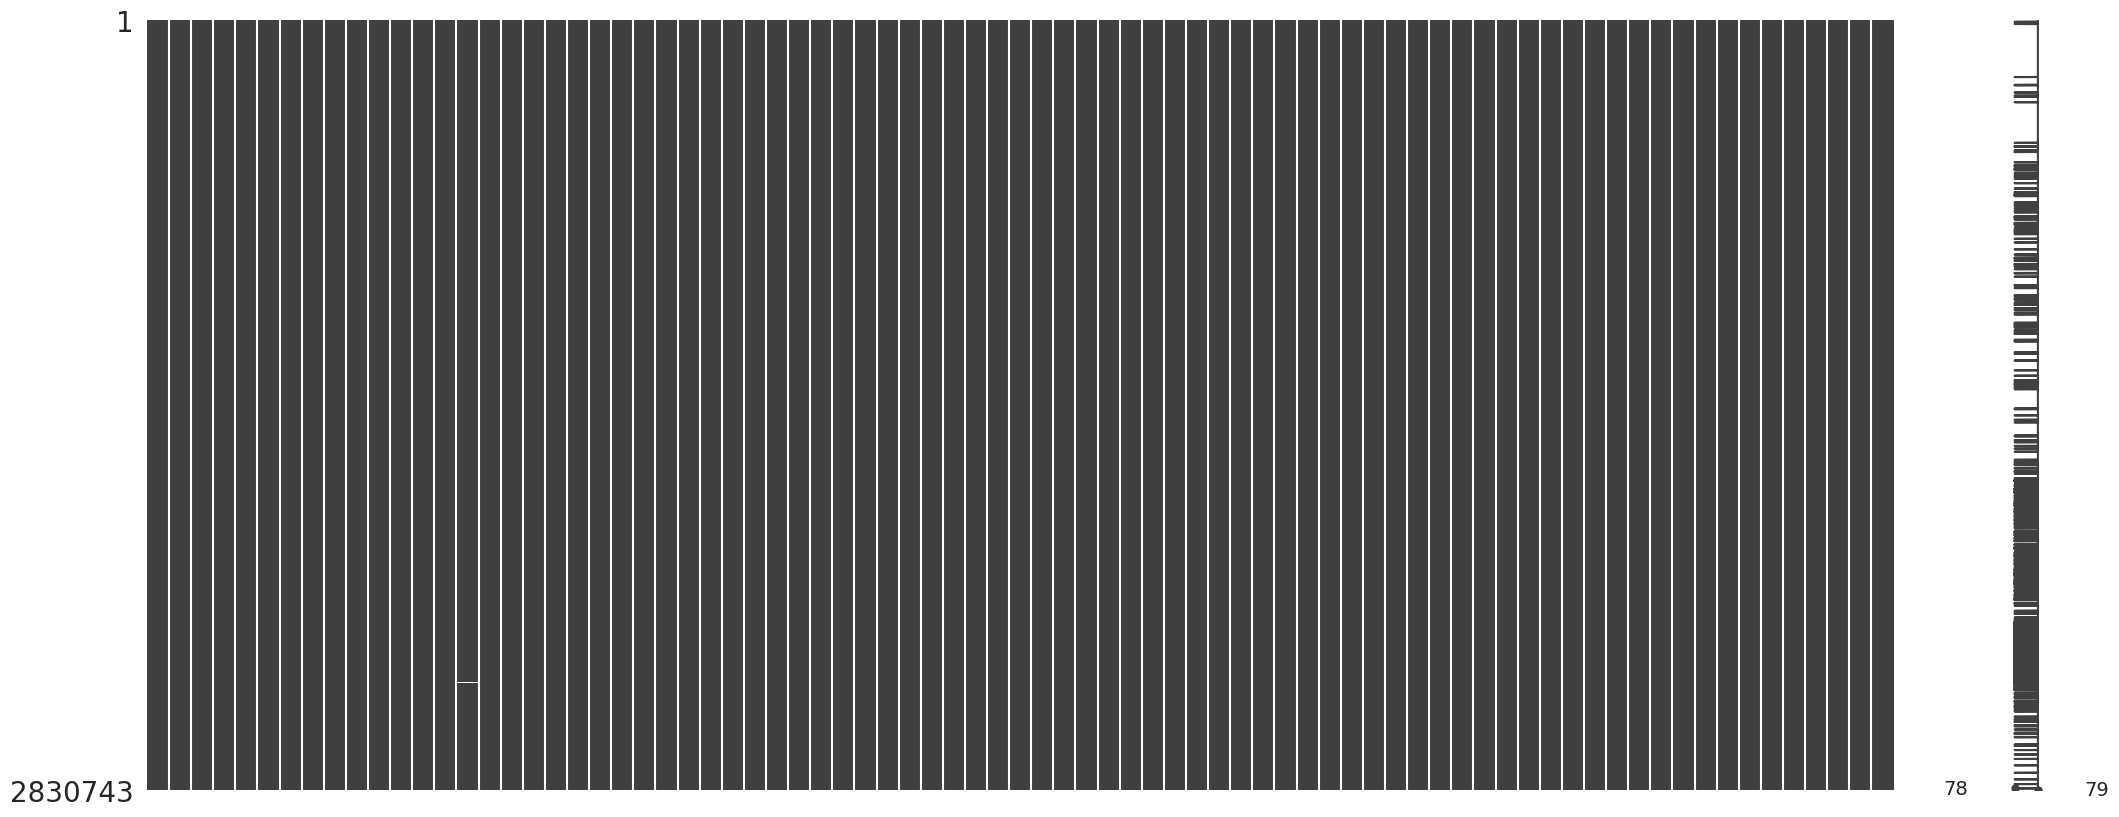

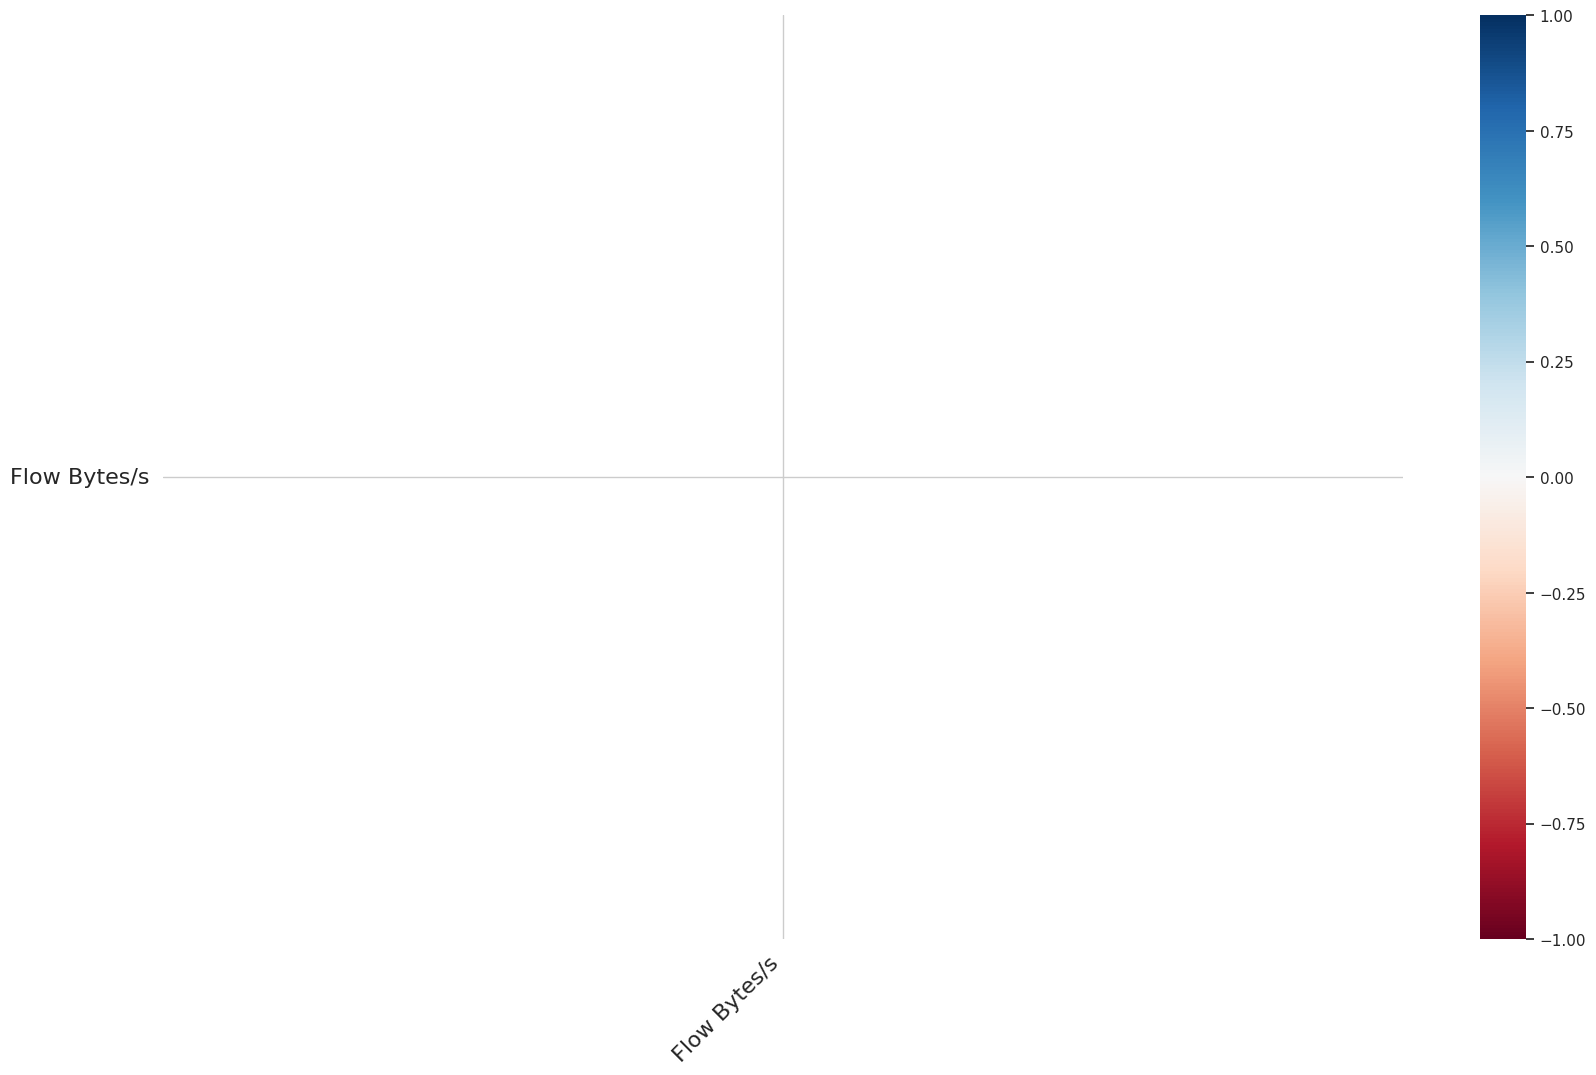

In [6]:
# ==========================================
# 🔍 Step 4: Missing and Duplicate Values
# ==========================================
# Count of missing values
import pandas as pd
import matplotlib.pyplot as plt
import missingno as msno

# --- Missing values analysis ---
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})

missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values(by='Percentage', ascending=False)

print("🔍 Missing values summary:")
print(missing_df)

# --- Duplicate values analysis ---
duplicate_count = df.duplicated().sum()
print(f"\n🧾 Duplicate rows in dataset: {duplicate_count}")

# --- Visualizing missing values ---
print("--- Visualizing missing values ---")
msno.matrix(df)
plt.show()

msno.heatmap(df)
plt.show()

Numerical columns: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std'] ...
Categorical columns: ['Label'] ...


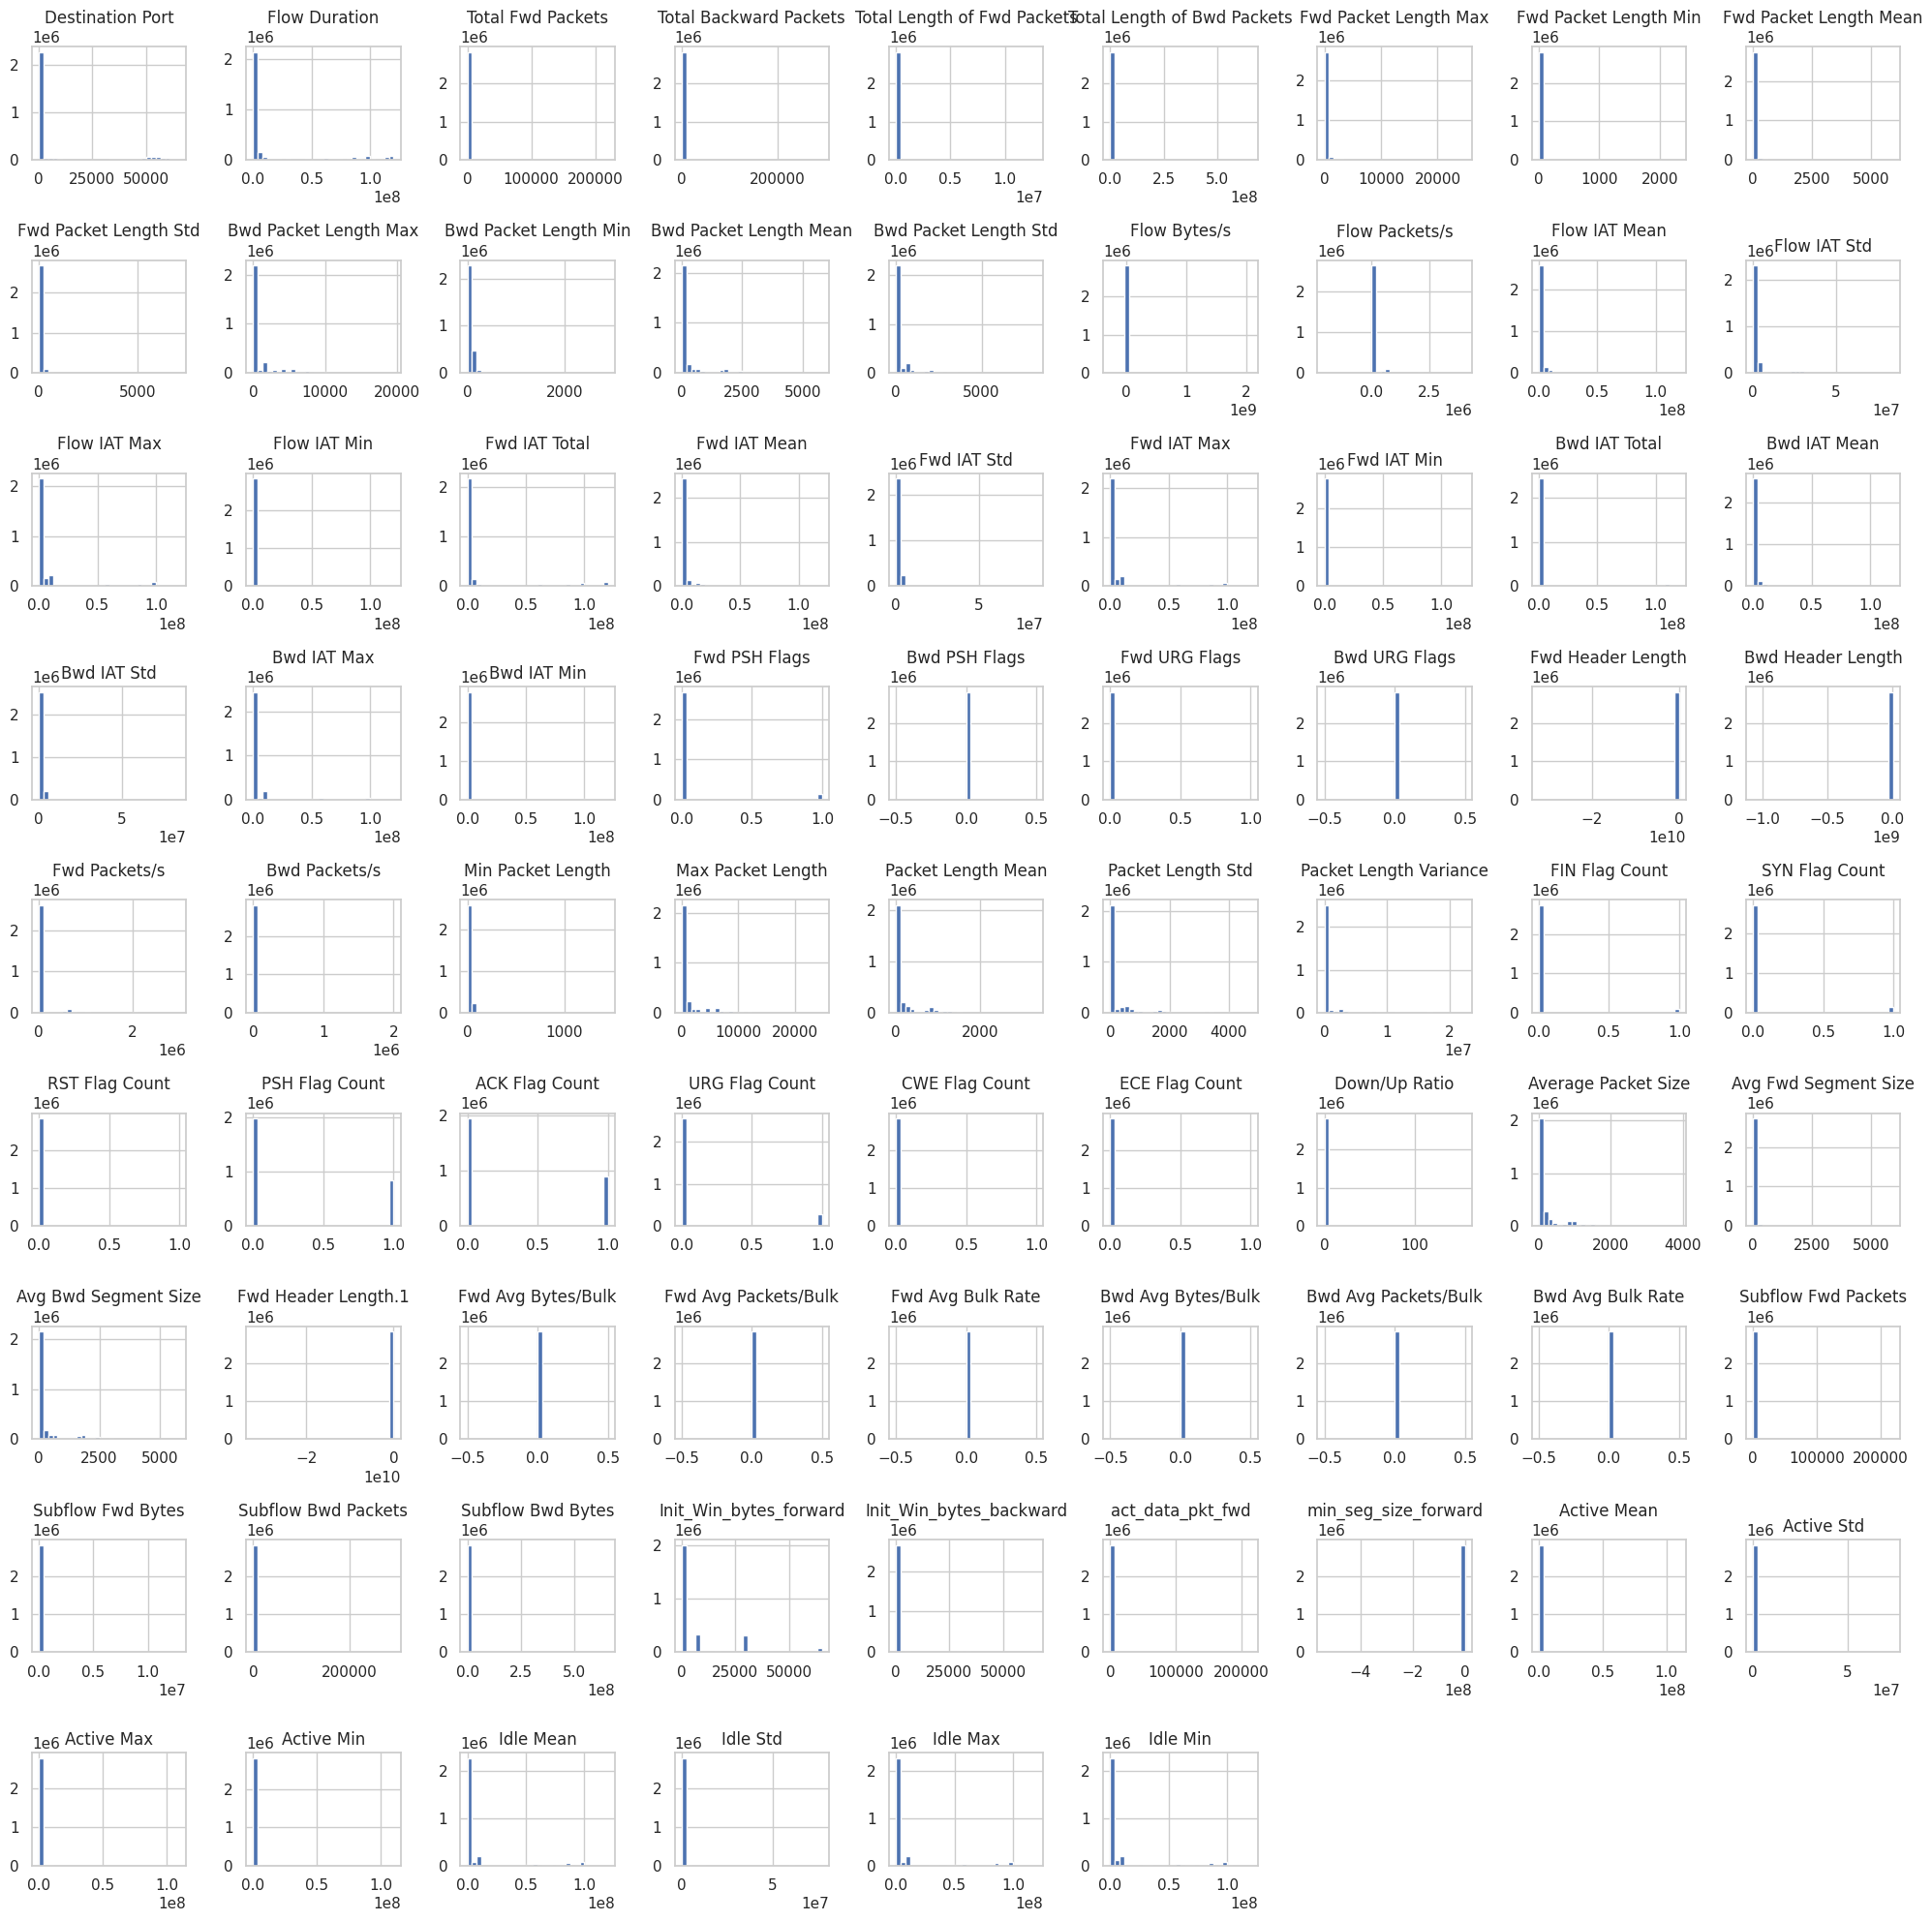

In [ ]:
# ===============================
# 🔢 Step 5: Univariate Analysis
# ===============================

import numpy as np
import matplotlib.pyplot as plt

# Strip column names spaces
df.columns = df.columns.str.strip()

# Detect numeric and categorical columns again
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical columns:", num_cols[:10], '...')
print("Categorical columns:", cat_cols[:10], '...')

# Replace inf/-inf with NaN
df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan)

# Drop rows with NaN in numeric columns
df_clean = df.dropna(subset=num_cols)

# Plot histograms
df_clean[num_cols].hist(figsize=(20, 20), bins=30)
plt.tight_layout()
plt.show()

In [8]:
# import pandas as pd

# # Sample data creation with duplicates
# data = {
#     'A': ['foo', 'bar', 'foo', 'baz', 'foo', 'bar', 'baz', 'foo', 'foo', 'bar'],
#     'B': ['one', 'one', 'two', 'two', 'one', 'one', 'two', 'two', 'one', 'one'],
#     'C': ['x', 'y', 'x', 'y', 'x', 'y', 'x', 'y', 'x', 'y'],
#     'D': [1, 2, 1, 2, 1, 2, 2, 2, 1, 2]  # Some extra column to vary rows
# }

# df = pd.DataFrame(data)

# # Introduce exact duplicate rows intentionally
# df = pd.concat([df, df.iloc[2:5]], ignore_index=True)

# print("Sample DataFrame:")
# print(df)

# # Now duplicate summary for columns A, B, C
# columns_to_check = ['A', 'B', 'C']

# for col in columns_to_check:
#     print(f"\n🔍 Duplicate summary for column: '{col}'")

#     duplicates_df = df[df.duplicated(keep=False)]

#     total_per_value = df[col].value_counts().rename("Total")
#     dup_per_value = duplicates_df[col].value_counts().rename("Duplicate Count")

#     summary = pd.concat([total_per_value, dup_per_value], axis=1).fillna(0)
#     summary["Duplicate %"] = (summary["Duplicate Count"] / summary["Total"]) * 100
#     summary["Duplicate Count"] = summary["Duplicate Count"].astype(int)
#     summary = summary.sort_values(by="Duplicate %", ascending=False)

#     print(summary)


# cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()
for col in cat_cols:
    print(f"\n🔍 Duplicate summary for column: '{col}'")

    # Get all duplicate rows (including all occurrences)
    duplicates_df = df[df.duplicated(keep=False)]

    # Total count per category value
    total_per_value = df[col].value_counts().rename("Total")

    # Duplicate count per category value
    dup_per_value = duplicates_df[col].value_counts().rename("Duplicate Count")

    # Combine into a summary table
    summary = pd.concat([total_per_value, dup_per_value], axis=1).fillna(0)

    # Calculate percentage
    summary["Duplicate %"] = (summary["Duplicate Count"] / summary["Total"]) * 100

    # Convert duplicate count to int for cleaner display
    summary["Duplicate Count"] = summary["Duplicate Count"].astype(int)

    # Sort by highest % of duplicates
    summary = summary.sort_values(by="Duplicate %", ascending=False)

    # Display result
    print(summary)


🔍 Duplicate summary for column: 'Label'
                              Total  Duplicate Count  Duplicate %
Label                                                            
PortScan                     158930           101501    63.865224
SSH-Patator                    5897             2826    47.922673
FTP-Patator                    7938             2457    30.952381
DoS Hulk                     231073            59564    25.777135
BENIGN                      2273097           236257    10.393617
DoS slowloris                  5796              507     8.747412
DoS Slowhttptest               5499              323     5.873795
Web Attack � Brute Force       1507               62     4.114134
Bot                            1966               19     0.966429
DoS GoldenEye                 10293               14     0.136015
DDoS                         128027               20     0.015622
Web Attack � XSS                652                0     0.000000
Infiltration                     36

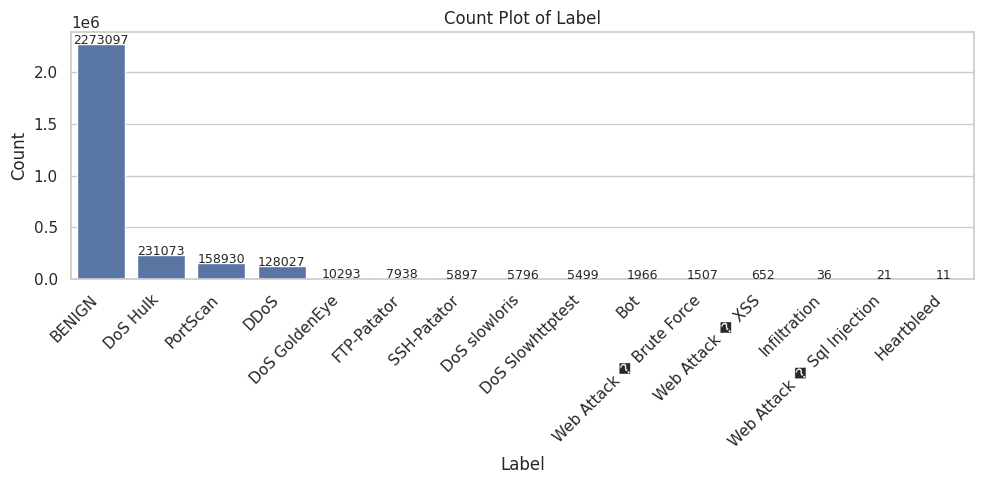

In [11]:
# ===============================
# 📊 Step 6: Categorical Features
# ===============================

import matplotlib.pyplot as plt
import seaborn as sns

# for col in cat_cols[:10]:  # Limiting to first 10 for brevity
import matplotlib.pyplot as plt
import seaborn as sns

for col in cat_cols:
    # Get unique values count
    num_unique = df[col].nunique()

    # # Skip if too many unique values (optional)
    # if num_unique > 50:
    #     print(f"⚠️ Skipping '{col}' (too many categories: {num_unique})")
    #     continue

    plt.figure(figsize=(max(10, num_unique * 0.6), 5))  # Dynamically adjust width
    order = df[col].value_counts().index
    ax = sns.countplot(data=df, x=col, order=order)

    # Add counts on top of bars
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.text(
                p.get_x() + p.get_width() / 2.,
                height + 0.5,
                int(height),
                ha="center",
                fontsize=9,
                rotation=90 if num_unique > 15 else 0  # Rotate numbers for crowded plots
            )

    plt.xticks(rotation=45 if num_unique <= 20 else 90, ha='right')
    plt.title(f'Count Plot of {col}')
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

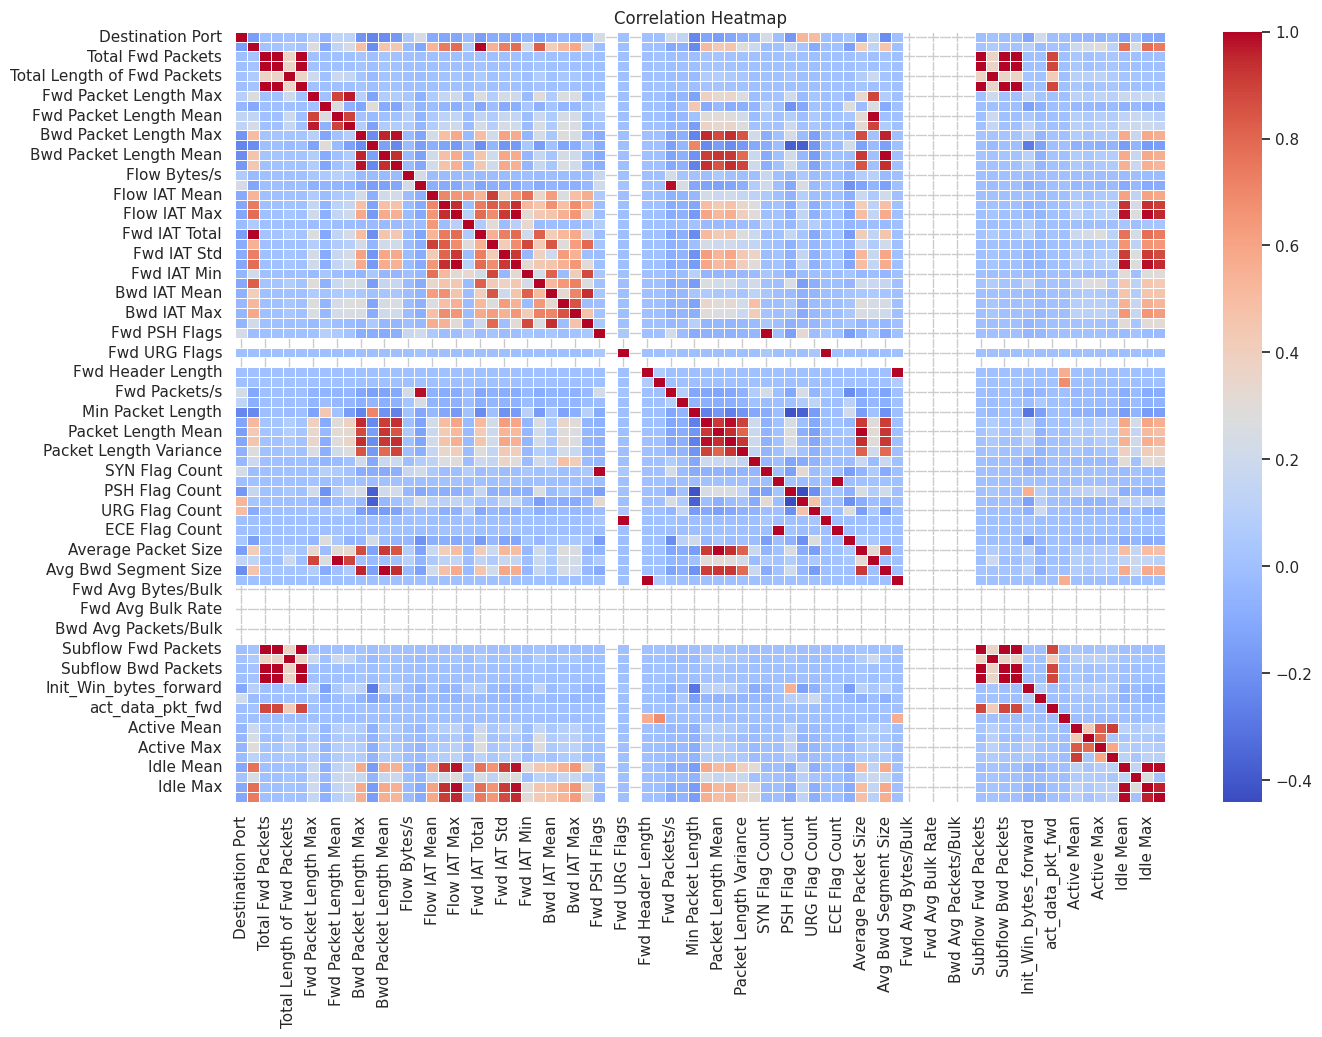

,,0
Total Length of Bwd Packets,Subflow Bwd Bytes,1.000000
Subflow Fwd Bytes,Total Length of Fwd Packets,0.999999
Subflow Bwd Packets,Total Fwd Packets,0.999070
Total Backward Packets,Subflow Fwd Packets,0.999070
Fwd IAT Total,Flow Duration,0.998560
...,...,...
Bwd IAT Total,Fwd IAT Total,0.819413
Average Packet Size,Packet Length Variance,0.816624
Fwd IAT Min,Bwd IAT Mean,0.815865
Packet Length Variance,Packet Length Mean,0.806212


In [ ]:
# ===============================
# 🔁 Step 7: Correlation Analysis
# ===============================
# Correlation matrix
corr_matrix = df[num_cols].corr()

# Heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

# Highly correlated pairs
threshold = 0.8
high_corr = corr_matrix.abs().unstack().sort_values(ascending=False)
high_corr = high_corr[high_corr < 1].drop_duplicates()
high_corr[high_corr > threshold]

Number of highly correlated pairs (corr > 0.99): 27


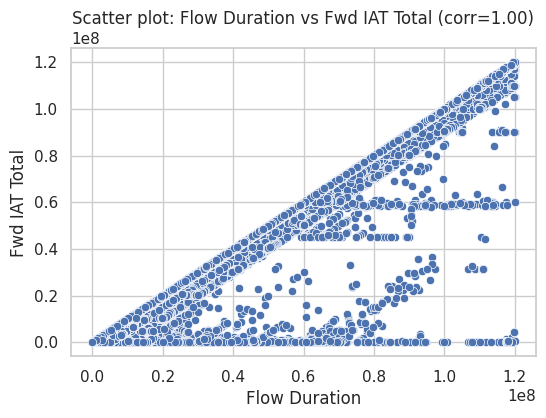

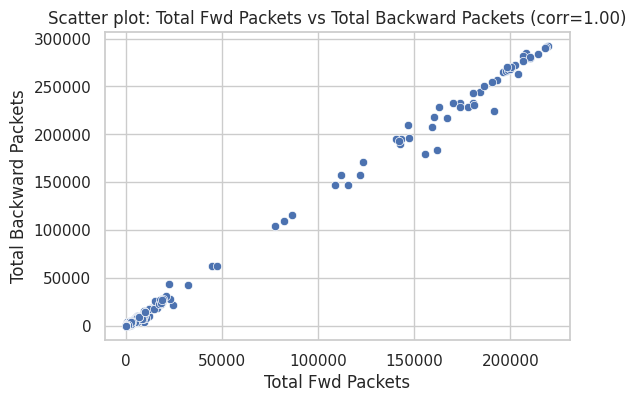

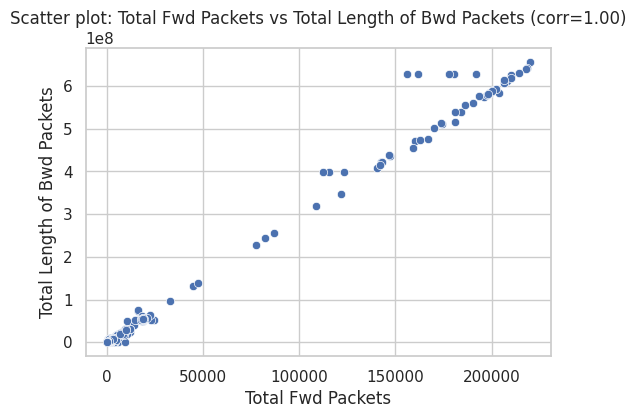

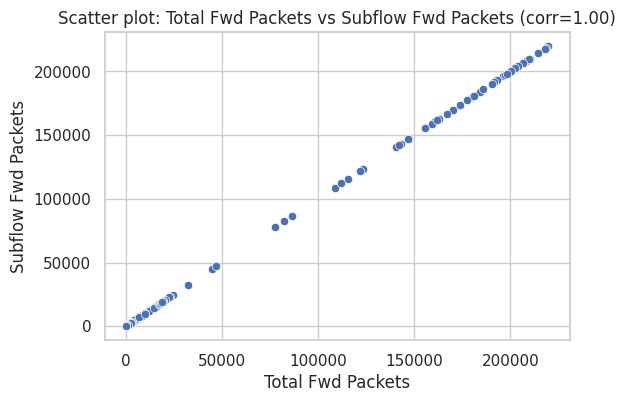

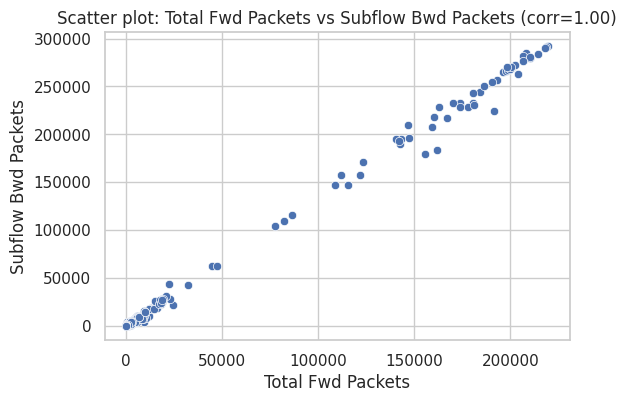

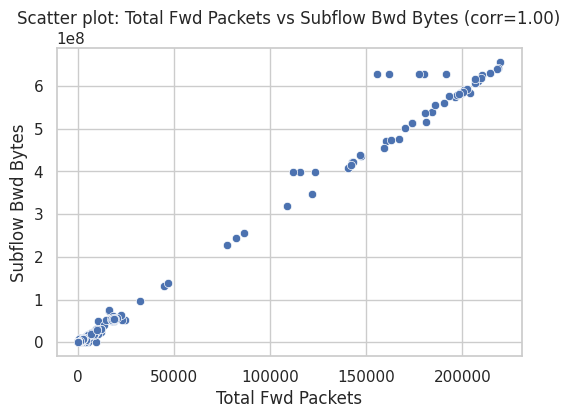

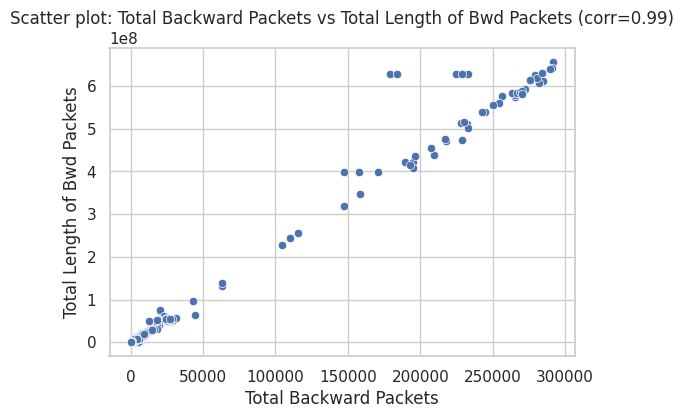

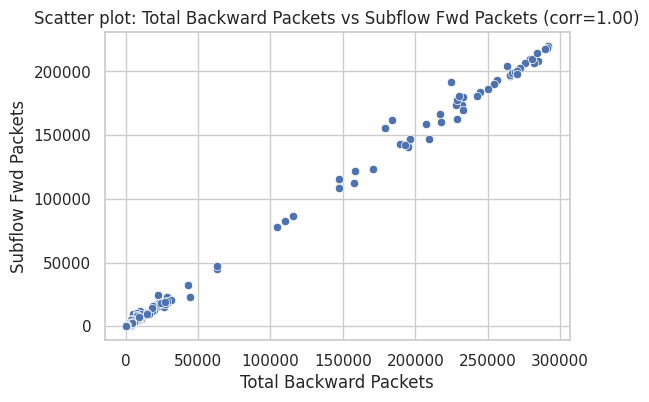

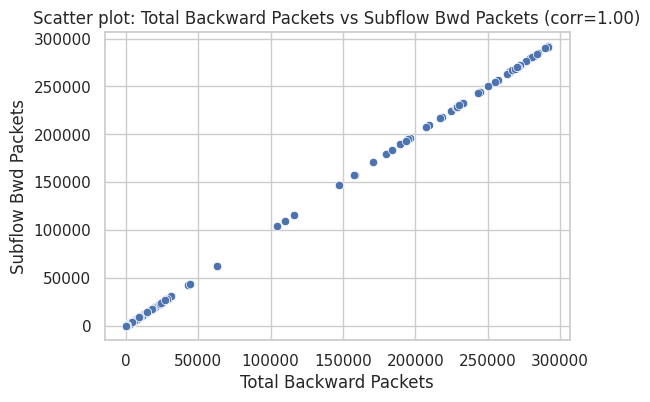

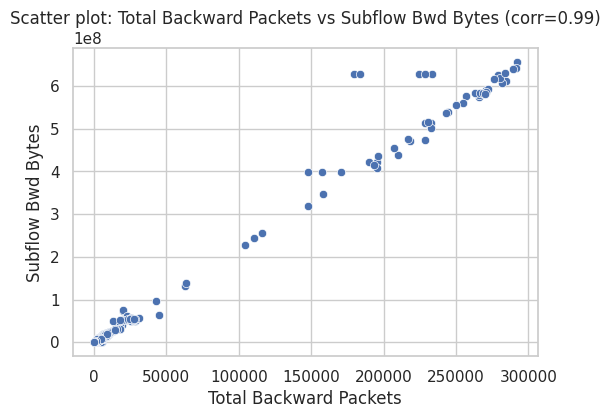

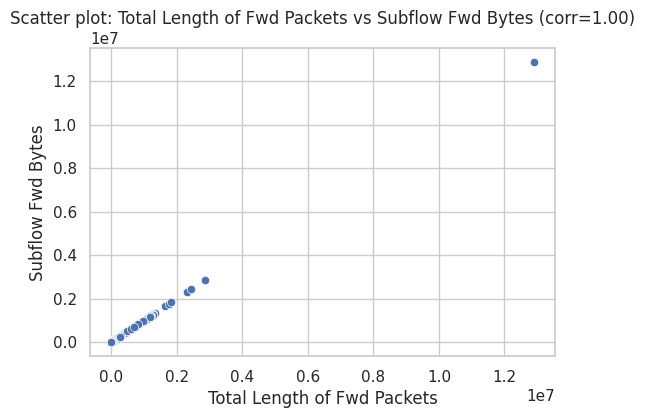

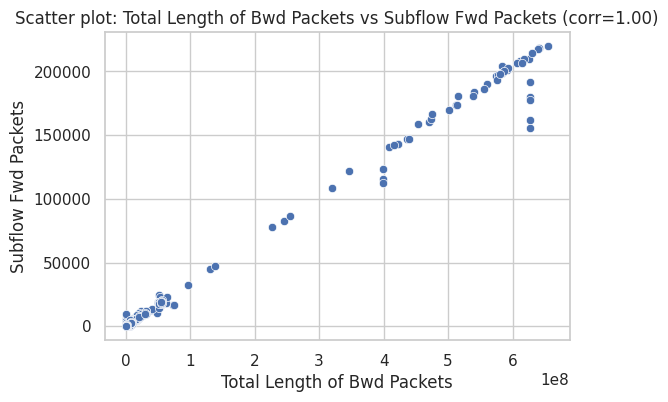

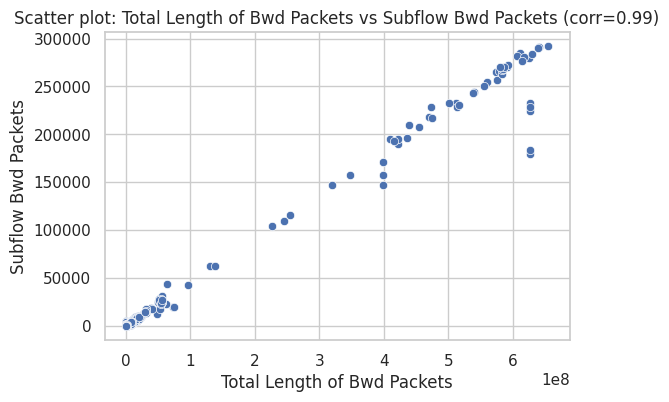

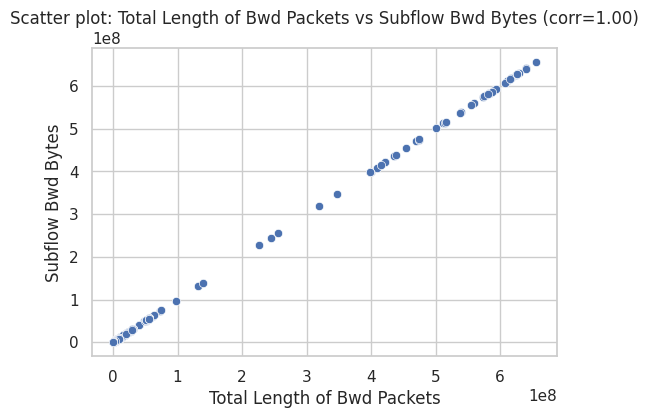

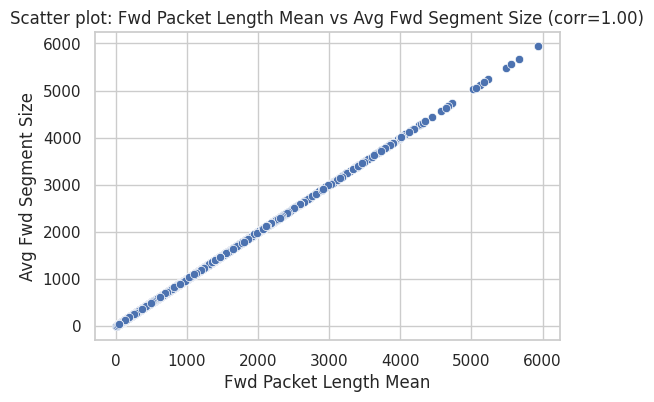

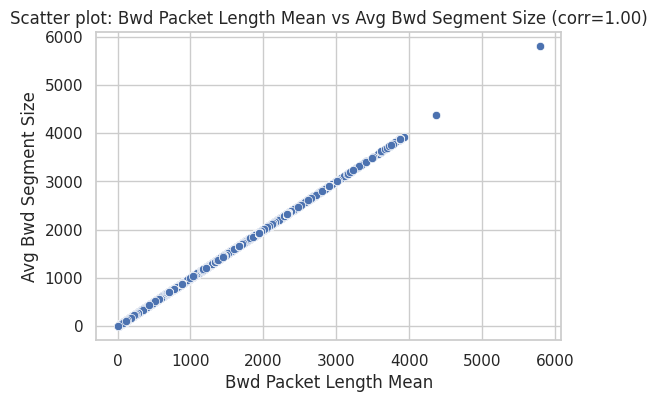

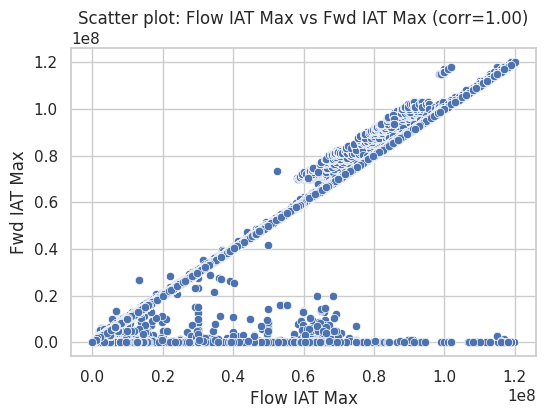

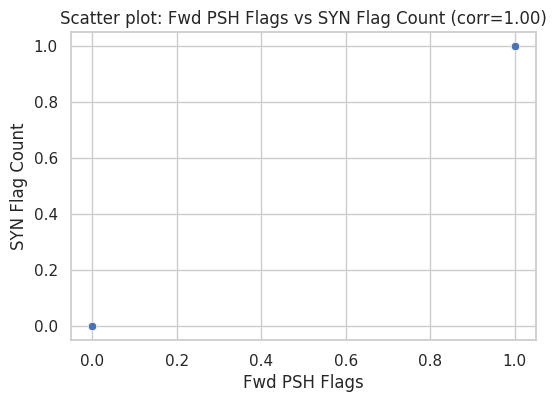

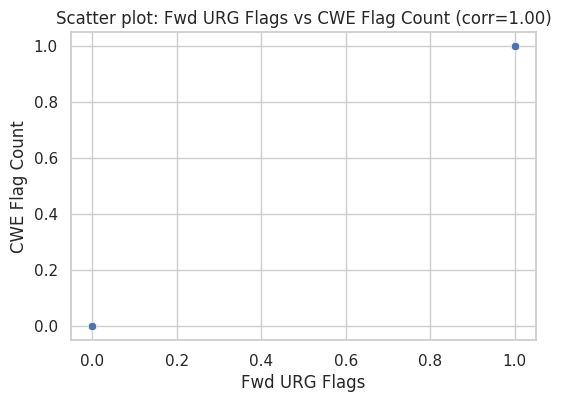

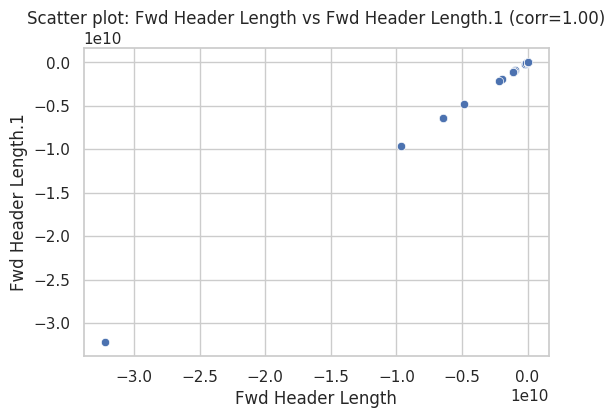

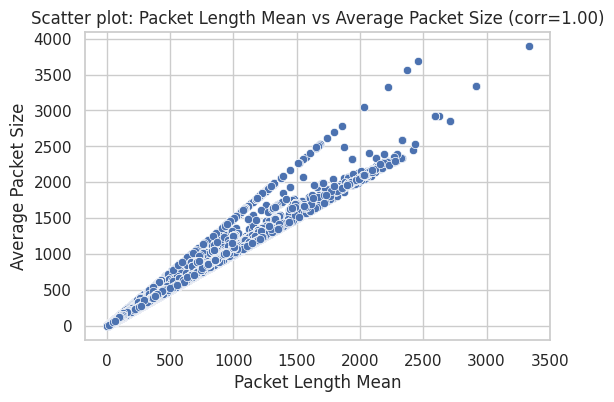

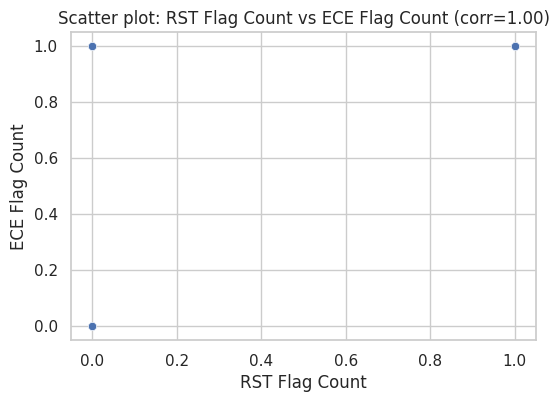

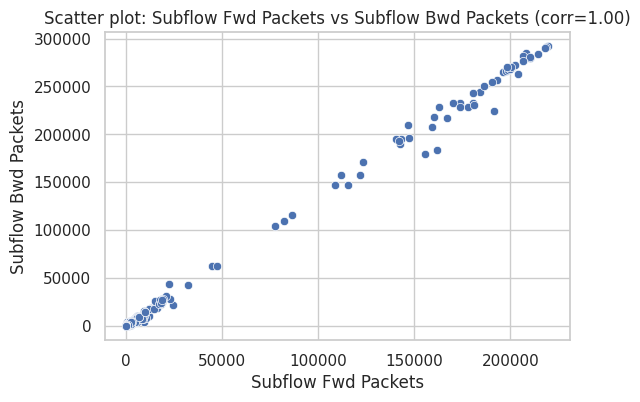

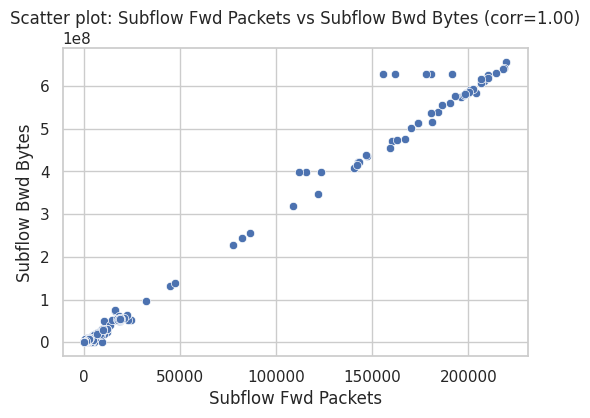

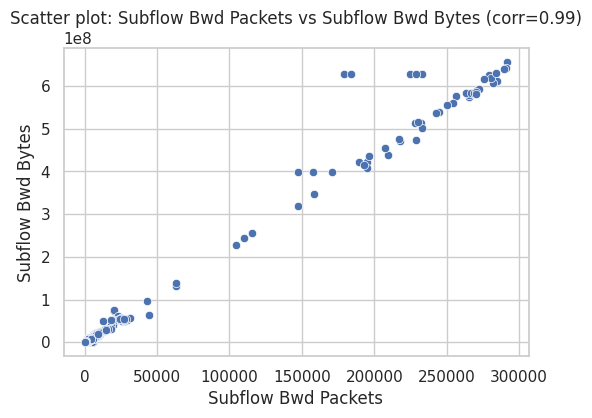

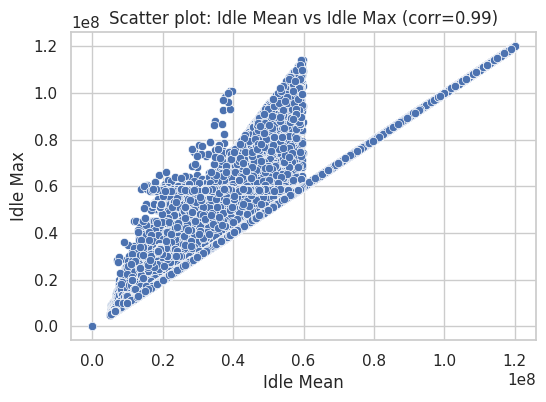

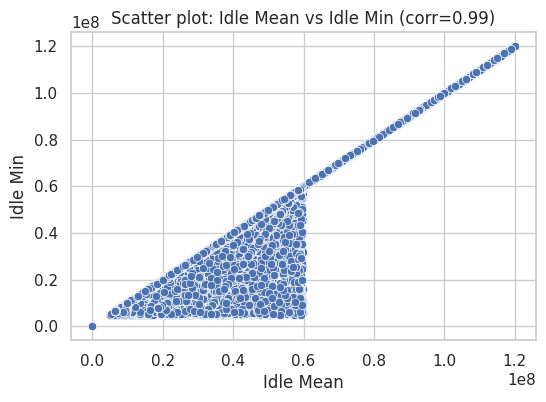

In [ ]:
# ===============================
# 🔄 Step 8: Scatter Plots / Pairplots for Highly Correlated Numerical Pairs
# ===============================

# Calculate absolute correlation matrix for numerical columns
corr_matrix = df[num_cols].corr().abs()

# Set correlation threshold
threshold = 0.99

# Find pairs with correlation greater than threshold (excluding self-correlation)
high_corr_pairs = []

for i in range(len(num_cols)):
    for j in range(i+1, len(num_cols)):
        corr_value = corr_matrix.iloc[i, j]
        if corr_value > threshold:
            high_corr_pairs.append((num_cols[i], num_cols[j], corr_value))

print(f"Number of highly correlated pairs (corr > {threshold}): {len(high_corr_pairs)}")

# Plot scatter plots for these pairs
for col1, col2, corr_value in high_corr_pairs:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df, x=col1, y=col2)
    plt.title(f'Scatter plot: {col1} vs {col2} (corr={corr_value:.2f})')
    plt.show()

# # Optional: Pairplot for the first few numerical columns (for overview)
# sns.pairplot(df[num_cols[:5]])
# plt.show()

Original number of columns: 79
Number of correlated groups: 12
Number of columns after removing redundancy: 62


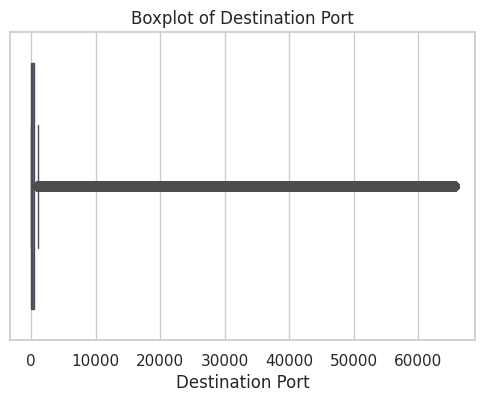

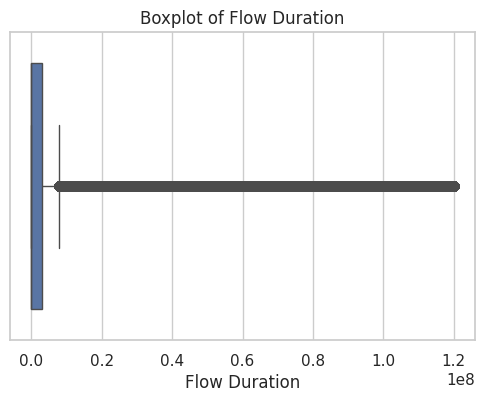

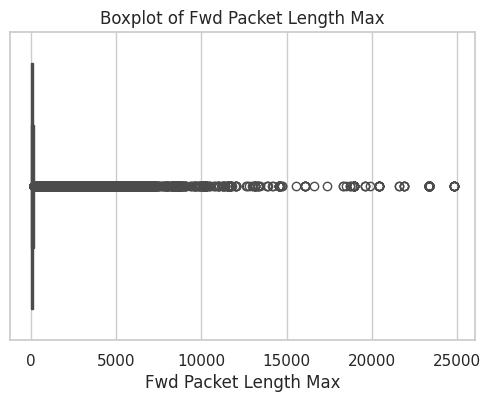

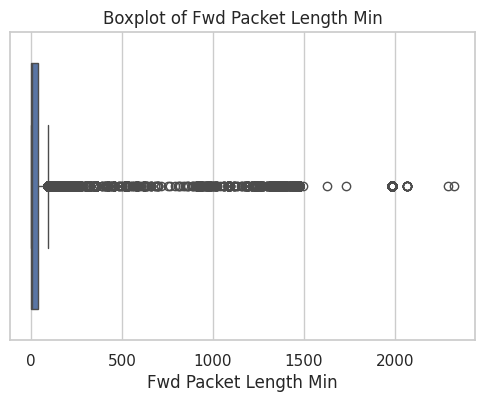

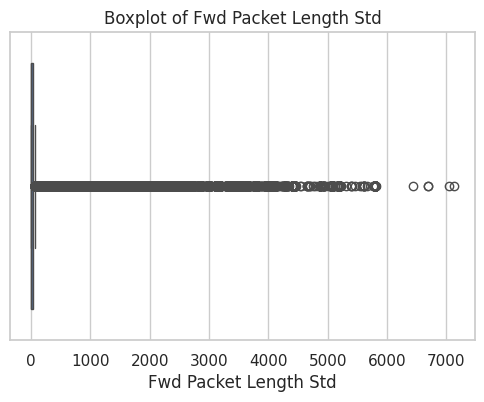

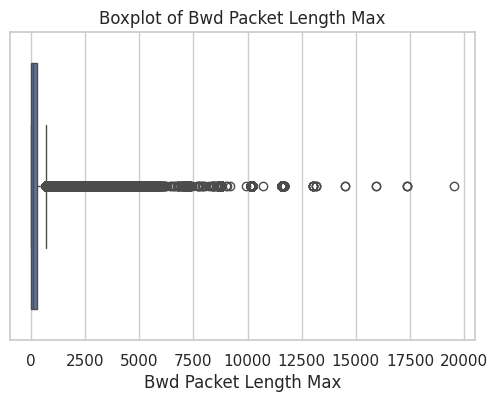

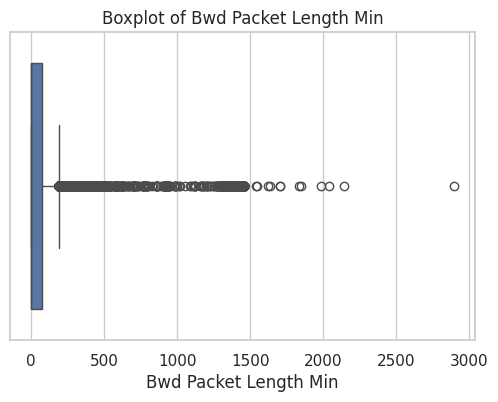

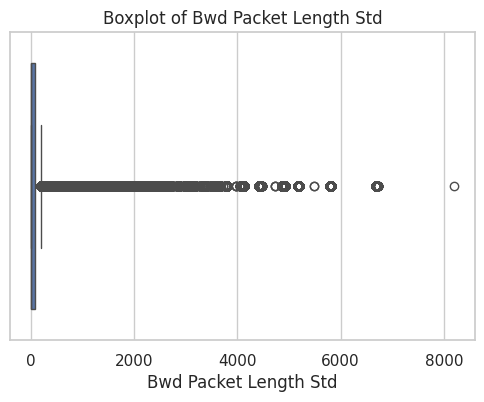

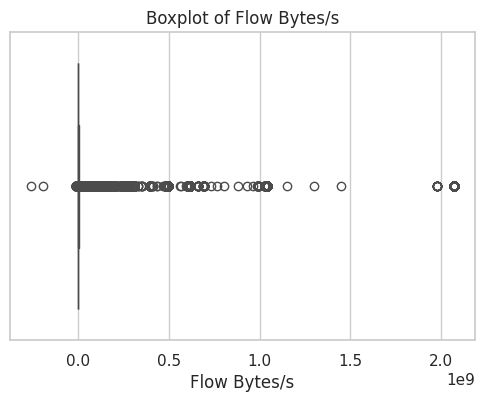

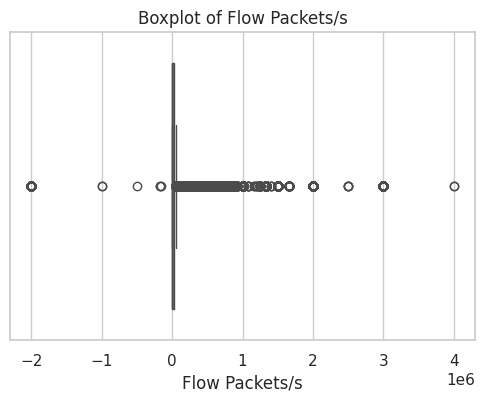

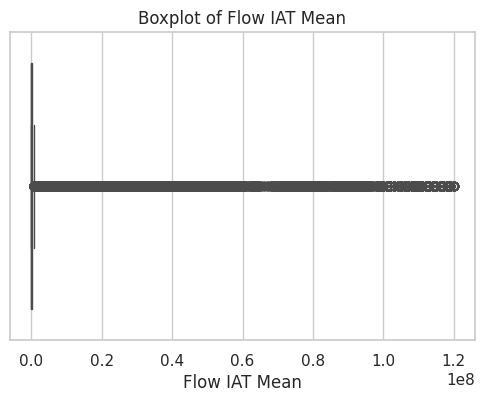

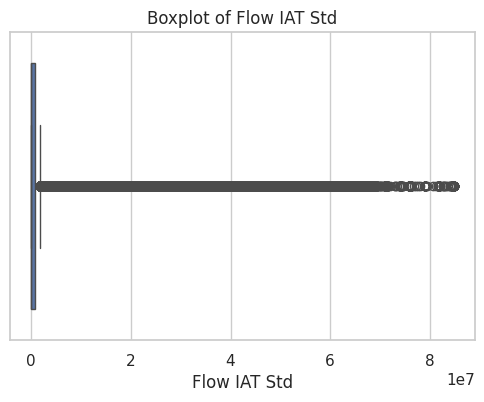

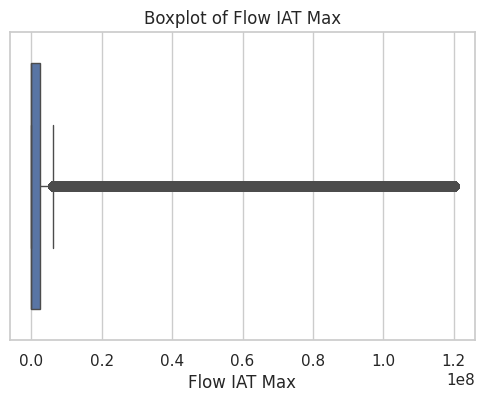

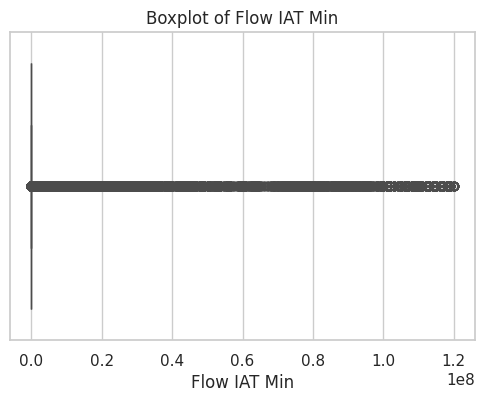

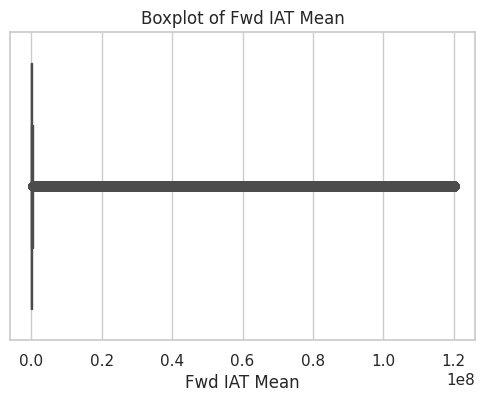

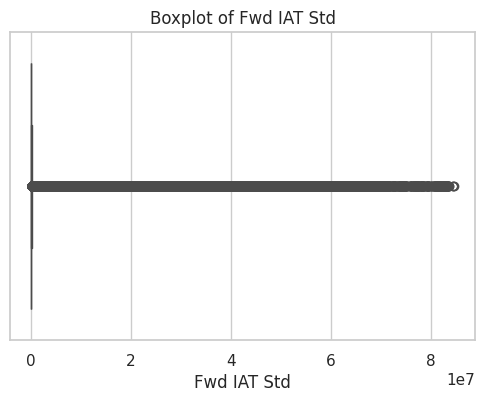

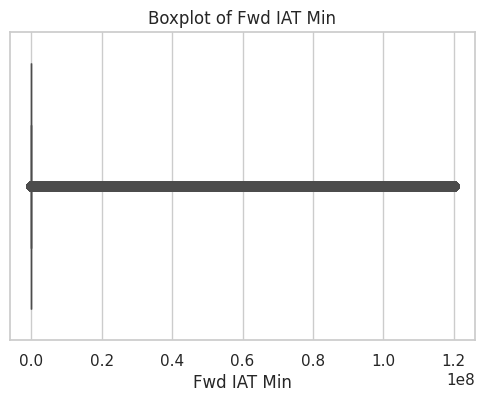

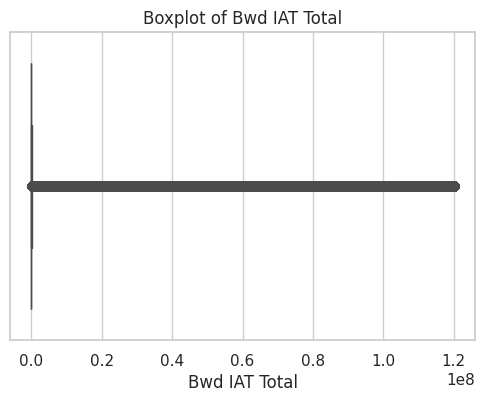

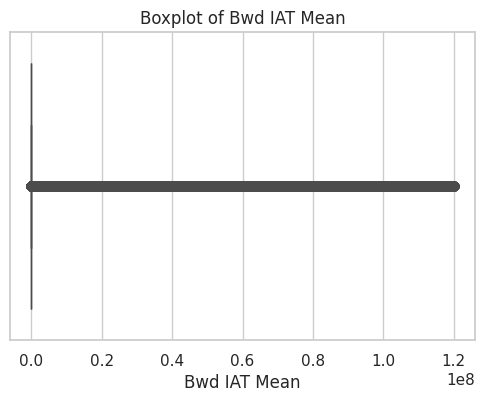

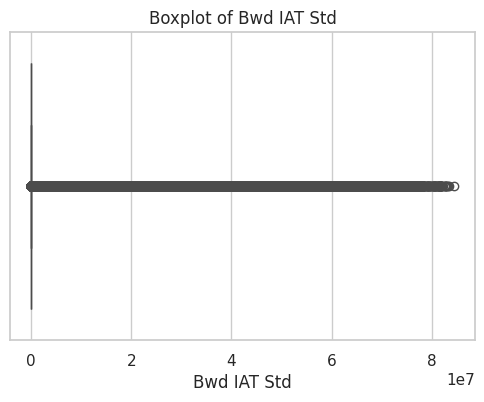

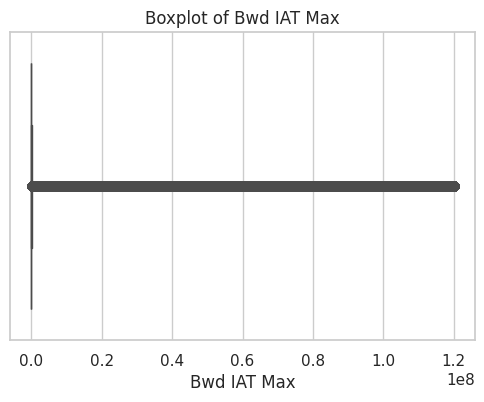

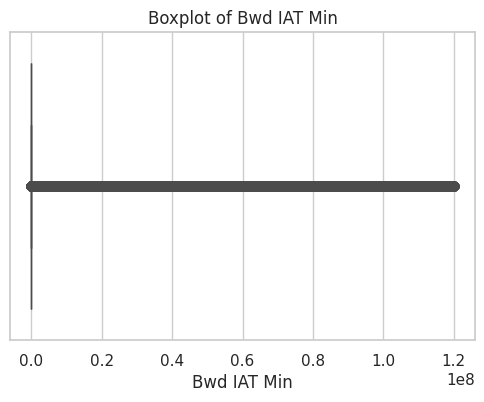

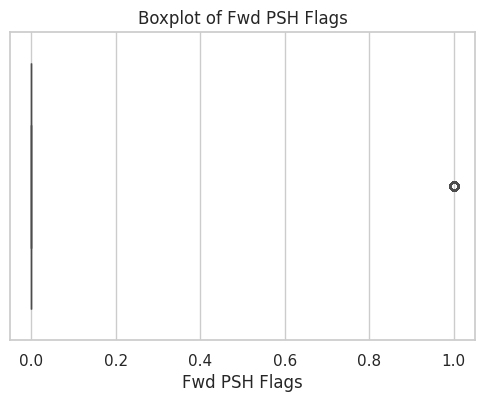

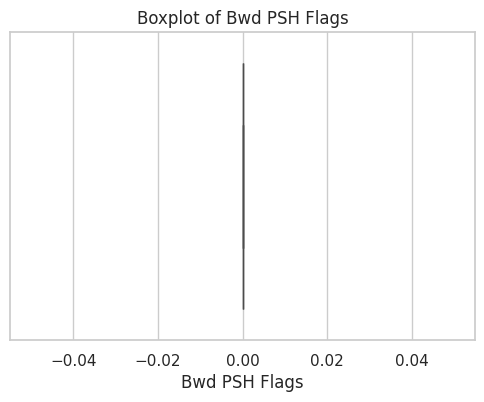

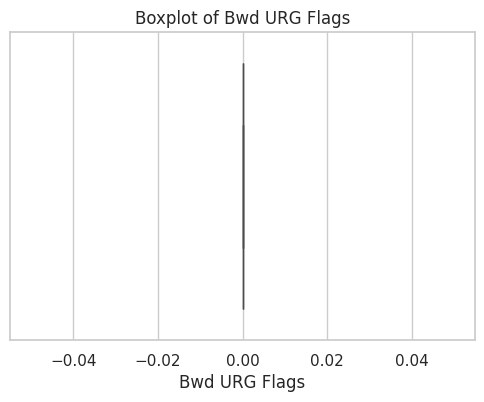

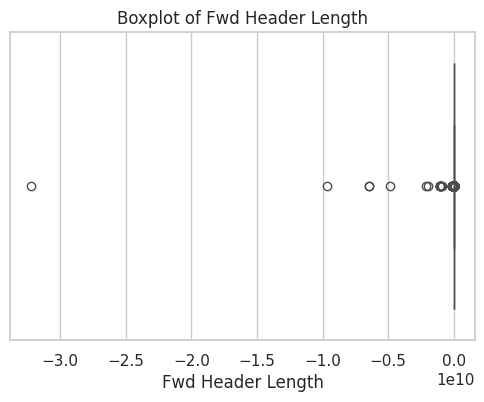

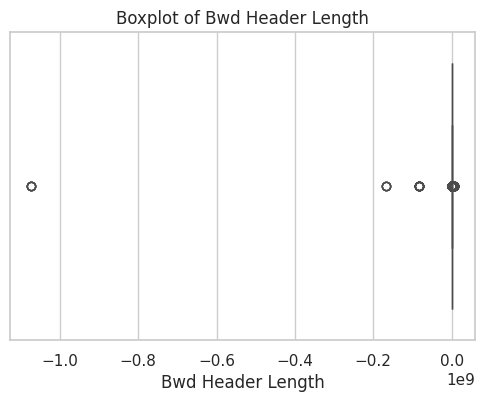

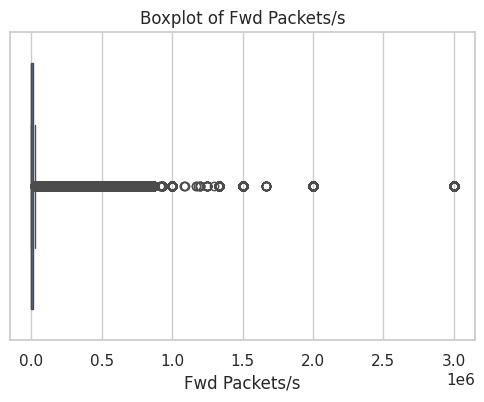

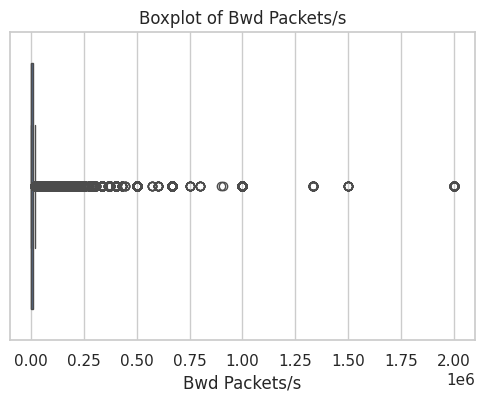

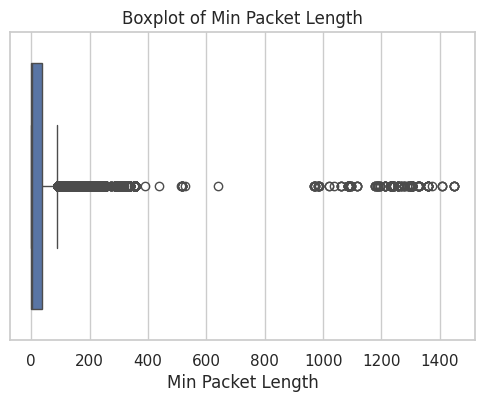

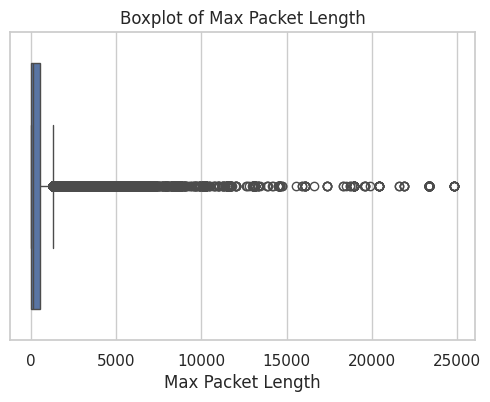

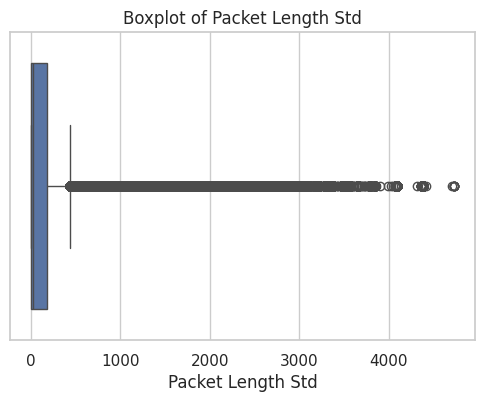

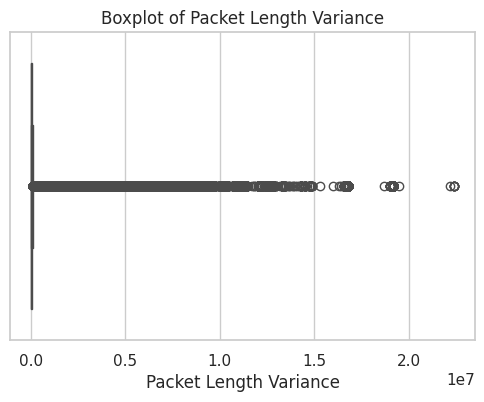

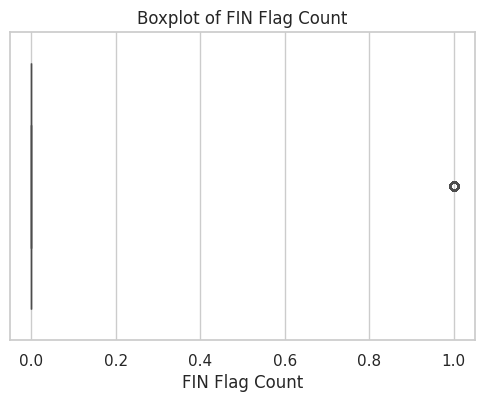

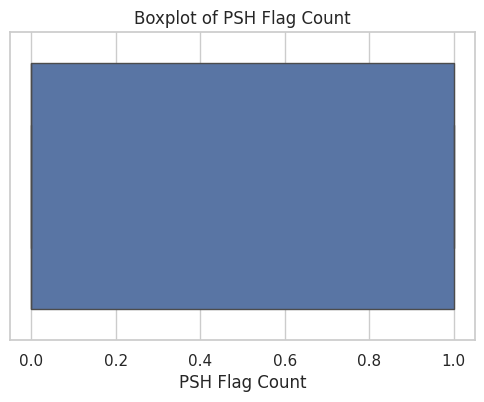

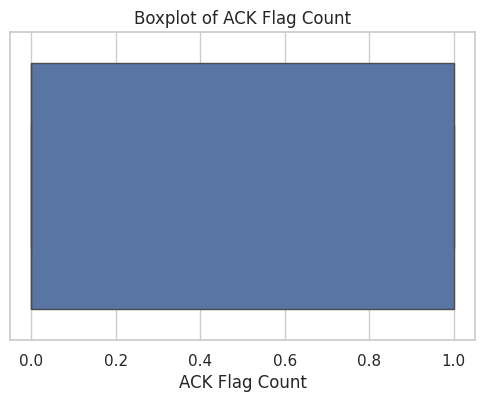

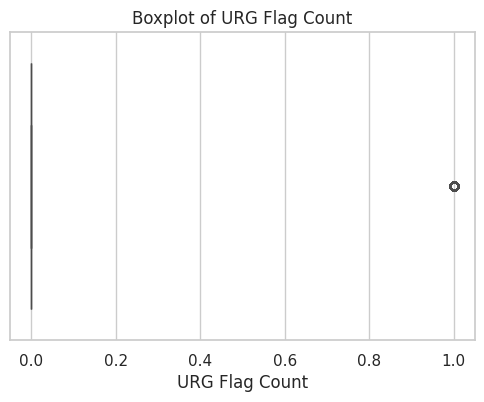

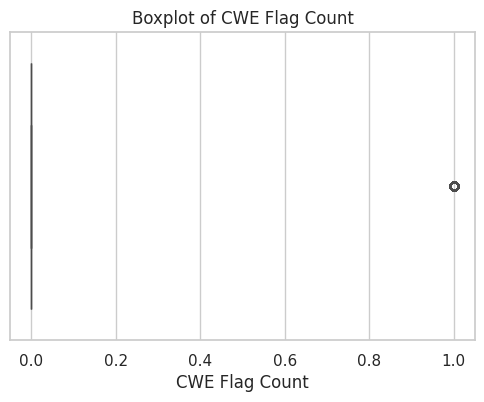

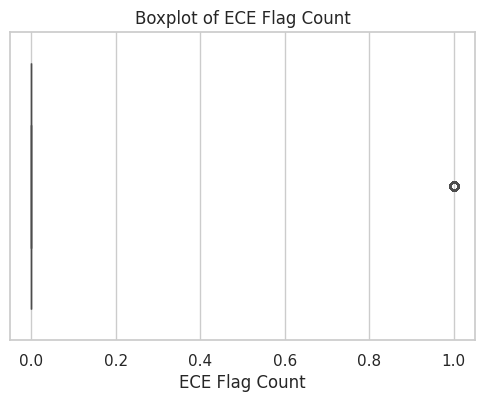

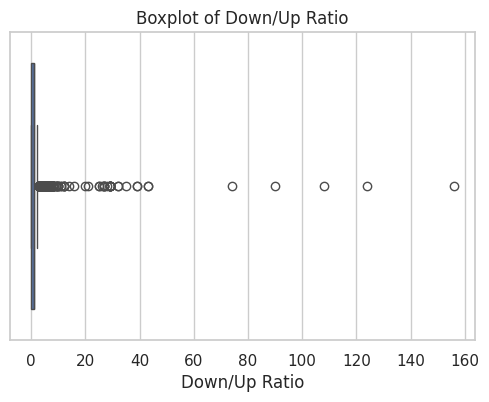

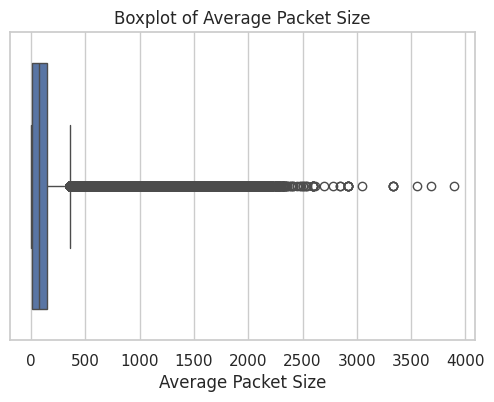

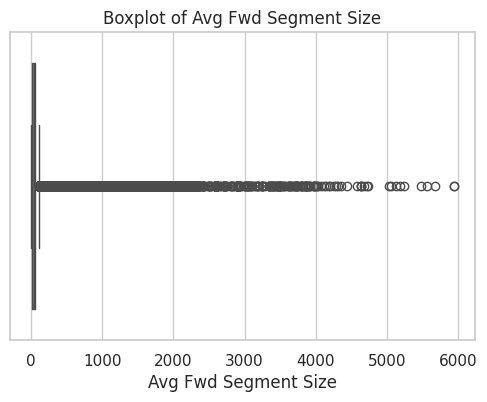

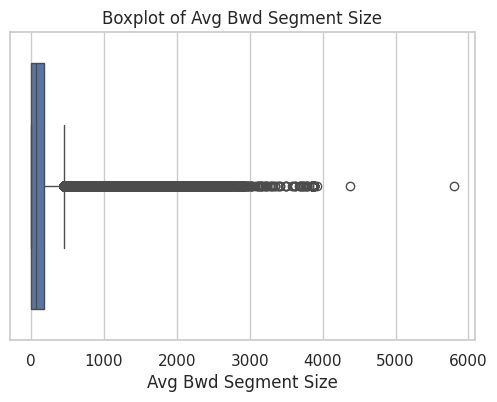

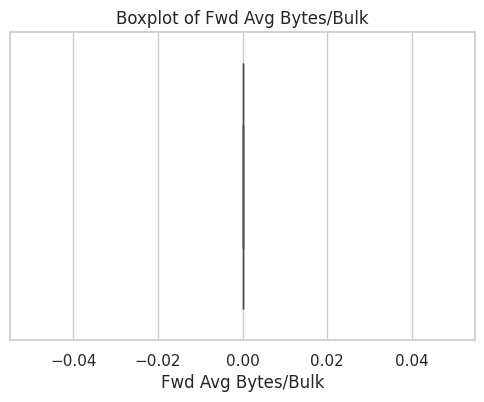

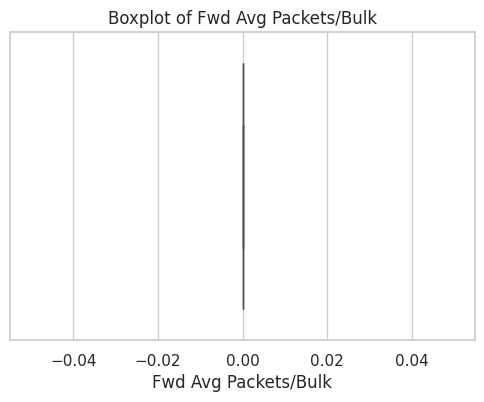

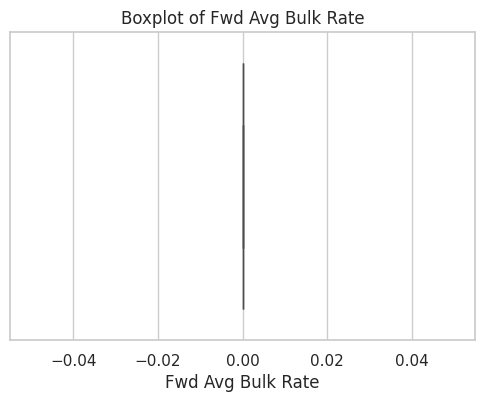

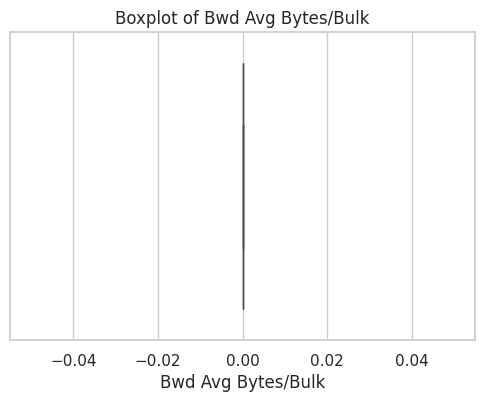

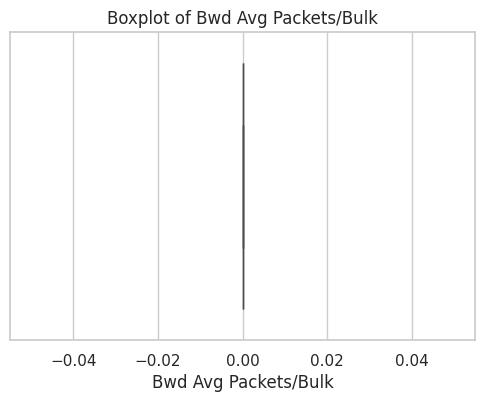

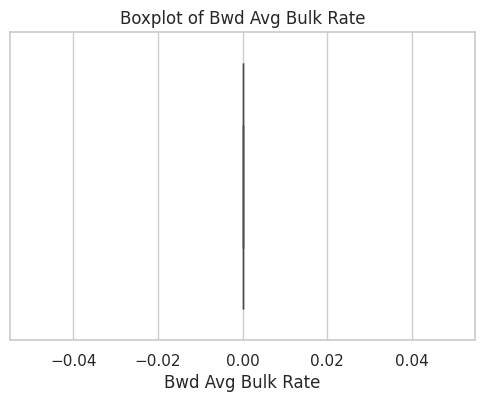

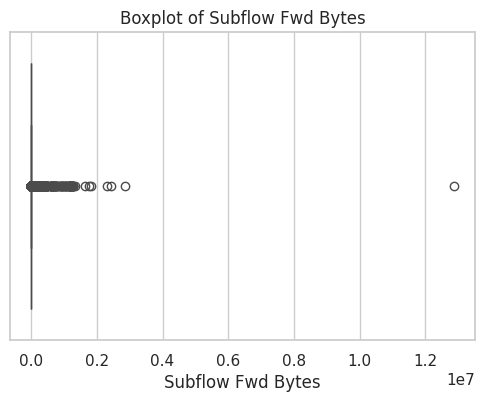

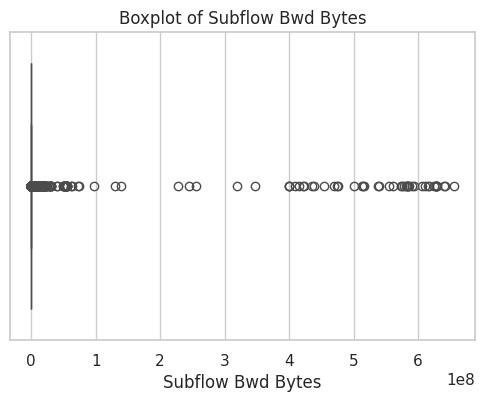

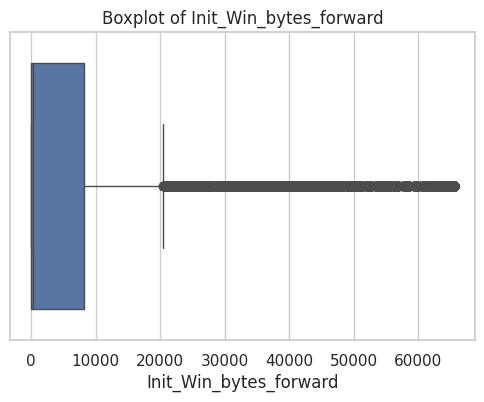

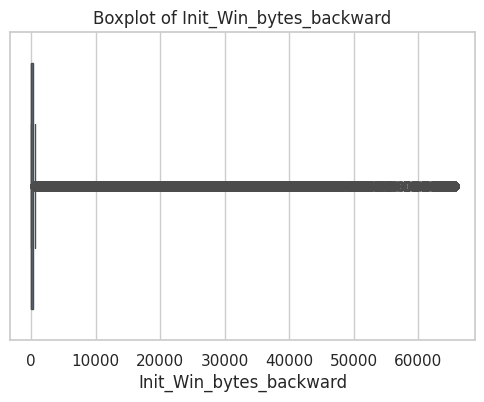

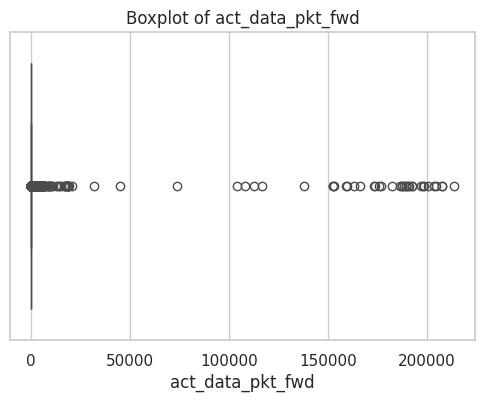

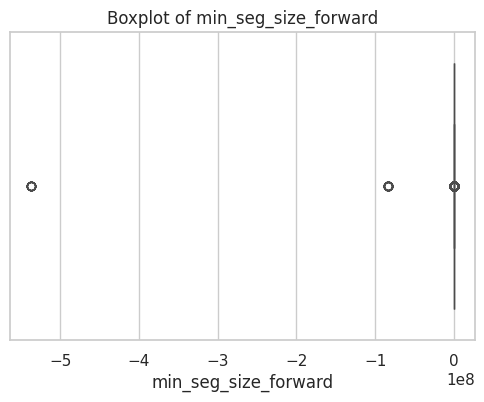

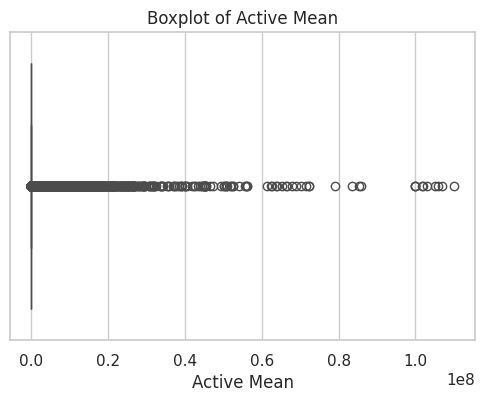

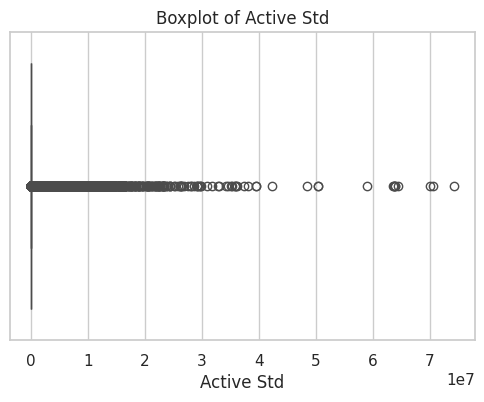

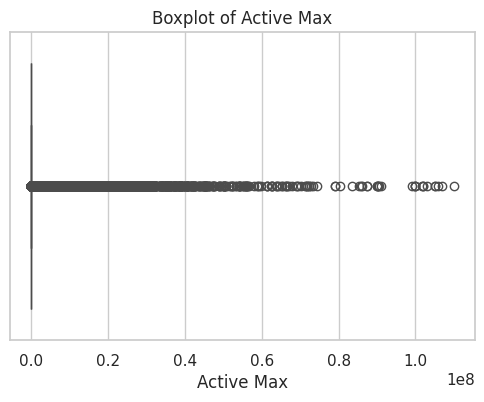

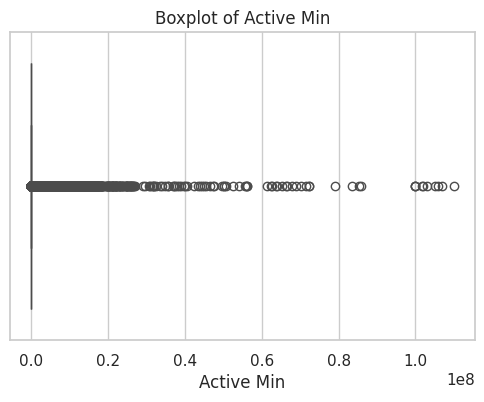

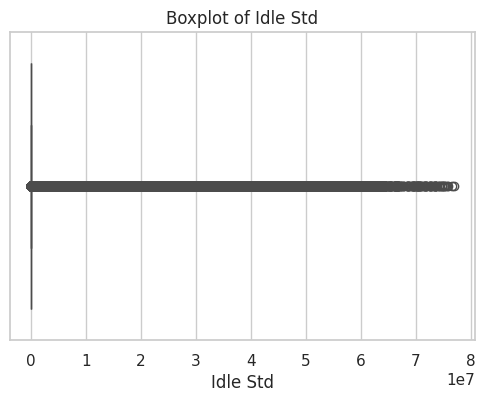

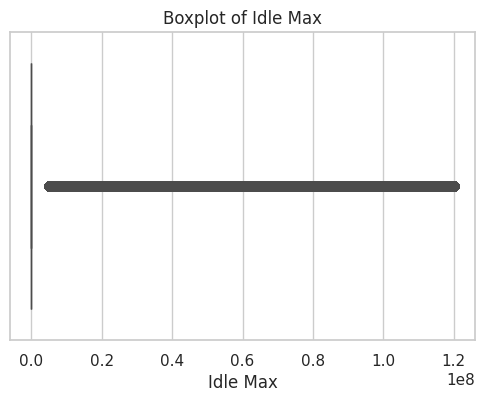

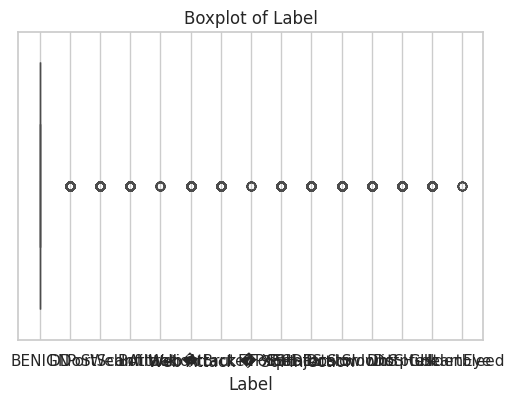

In [ ]:
# ===============================
# 🎯 Step 9: Boxplots for Unique Columns in Highly Correlated Pairs
# ===============================
# This step creates boxplots for the numerical columns involved in the
# 27 highly correlated pairs identified earlier (corr > 0.99).
# Remove redundant correlated columns using networkx graph

# Extract just the pairs (without correlation values) for graph edges
import networkx as nx
edges = [(col1, col2) for col1, col2, _ in high_corr_pairs]

# Build graph of correlated pairs
G = nx.Graph()
G.add_edges_from(edges)

# Find correlated groups (connected components)
correlated_groups = list(nx.connected_components(G))

# Pick one column to keep per group (e.g., first in sorted order)
columns_to_keep_from_corr = [sorted(list(group))[0] for group in correlated_groups]

# All columns involved in correlated groups
all_correlated_cols = set().union(*correlated_groups)

# Final columns = all columns minus redundant correlated columns (keep one per group)
final_columns = [col for col in df.columns if (col not in all_correlated_cols) or (col in columns_to_keep_from_corr)]

print(f"Original number of columns: {df.shape[1]}")  # e.g. 79
print(f"Number of correlated groups: {len(correlated_groups)}")
print(f"Number of columns after removing redundancy: {len(final_columns)}")

# Optional: create reduced dataframe
df_reduced = df[final_columns]

import matplotlib.pyplot as plt
import seaborn as sns

for col in final_columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df_reduced[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [ ]:
# ===============================
# 📌 Step 10: Outlier Detection
# ===============================

from scipy.stats import zscore

z_scores = np.abs(zscore(df[num_cols]))
outliers = (z_scores > 3).sum(axis=0)
print("Number of outliers per numerical column:")
print(pd.Series(outliers, index=num_cols).sort_values(ascending=False))

Number of outliers per numerical column:
URG Flag Count          268420
Idle Max                167656
Fwd IAT Max             167052
Flow IAT Max            166608
Bwd IAT Total           163812
                         ...  
Fwd Avg Bulk Rate            0
Fwd Avg Packets/Bulk         0
Fwd Avg Bytes/Bulk           0
PSH Flag Count               0
ACK Flag Count               0
Length: 78, dtype: int64
